
# Assignment 2 : Language Modeling, BM25 & Evaluation

**Student names**: Eskild Sæther <br>
**Group number**: 101 <br>
**Date**: 28.7.2026

## Important notes
Please read and follow these rules. Submissions that do not fulfill them may be returned.
1. You may work in groups of maximum 2 students.
2. Submit in **.ipynb** format only.
3. The assignment must be typed. Handwritten answers are not accepted.

**On libraries.** The TODO cells are yours to implement. numpy, pandas, scipy.sparse and matplotlib are fine underneath. Do not use libraries that implement a step for you, such as scikit-learn vectorizers or metrics, NLTK tokenizers, or IR evaluation packages.

**Due date**: 02.10.2026 23:59

### What you will do
- Build a **unigram document language model** with a **document-term matrix**.
- Rank documents for queries using **Jelinek-Mercer smoothing**.
- (Optional) Try **Dirichlet** and compare briefly.
- Rank the same queries using **BM25**.
- Evaluate and compare the two models using **Cranfield queries and qrels** (P@k, MAP, MRR).

---
## Dataset

Make sure the Cranfield files are placed next to the notebook:
- `cran.all.1400` — document collection (1400 docs)
- `cran.qry` — queries
- `cranqrel` — relevance judgments (qrels)

> Only the **document parsing** for cran.all.1400 code is provided below. You will implement the rest in the TODO cells.


### Load and parse documents (provided)

Run the cell to parse the Cranfield documents. Update the path so it points to your `cran.all.1400` file.


In [15]:
# Read 'cran.all.1400' and parse the documents into a suitable data structure
%load_ext autoreload
%autoreload 2
%reset -f

CRAN_PATH = r"./cran.all.1400"  # <-- change this!

def parse_cranfield(path):
    docs = {}
    current_id = None
    current_field = None
    buffers = {"T": [], "A": [], "B": [], "W": []}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(".I "):
                if current_id is not None:
                    docs[current_id] = {
                        "id": current_id,
                        "title": " ".join(buffers["T"]).strip(),
                        "abstract": " ".join(buffers["W"]).strip()
                    }
                current_id = int(line.split()[1])
                buffers = {k: [] for k in buffers}
                current_field = None
            elif line.startswith("."):
                tag = line[1:].strip()
                current_field = tag if tag in buffers else None
            else:
                if current_field is not None:
                    buffers[current_field].append(line)
    if current_id is not None:
        docs[current_id] = {
            "id": current_id,
            "title": " ".join(buffers["T"]).strip(),
            "abstract": " ".join(buffers["W"]).strip()
        }
    print(f"Parsed {len(docs)} documents.")
    return docs

docs = parse_cranfield(CRAN_PATH)
print(list(docs.items())[:1])  # peek at the first parsed doc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parsed 1400 documents.
[(1, {'id': 1, 'title': 'experimental investigation of the aerodynamics of a wing in a slipstream .', 'abstract': 'experimental investigation of the aerodynamics of a wing in a slipstream .   an experimental study of a wing in a propeller slipstream was made in order to determine the spanwise distribution of the lift increase due to slipstream at different angles of attack of the wing and at different free stream to slipstream velocity ratios .  the results were intended in part as an evaluation basis for different theoretical treatments of this problem .   the comparative span loading curves, together with supporting evidence, showed that a substantial part of the lift increment produced by the slipstream was due to a /destalling/ or boundary-layer-control effect .  the integrated remaining lift increment, after subtracting this destalling lift, was found to agree well with a

## 2.1 Ranking Models

You will create a **unigram language model** per document, using a **document-term matrix**, and score queries with **Jelinek-Mercer smoothing**. You will then rank the same queries with **BM25**, using the same matrix.

### 2.1.1 Preprocessing

Implement a simple tokenizer/normalizer (e.g., lowercasing, punctuation removal and stopword removal) and apply it to each document

- Return a list of tokens for each document.


In [16]:
# TODO: Implement preprocessing and apply to all documents



STOPWORDS = set("""a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her here here's hers
herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on on   ce only or other ought our ours ourselves out over own same shan't she
she'd she'll she's should shouldn't so some such than that that's the their theirs them themselves then there there's
these they they'd they'll they're they've this those through to too under until up very was wasn't we we'd we'll we're
we've were weren't what what's when when's where where's which while who who's whom why why's with won't would wouldn't
you you'd you'll you're you've your yours yourself yourselves""".split())

# Your code here

#Okay burde gå fint, jeg har gjort det her før, men greit å få det inn i fingrene.
for key, item in docs.items():
    item['title'] = str.lower(item['title'])
    item['abstract'] = str.lower(item['abstract'])

    item['title'] = str.replace(item['title'], ",", "")
    item['title'] = str.replace(item['title'], ".", "")
    item['title'] = str.replace(item['title'], "'", "")
    item['title'] = str.replace(item['title'], "/", "")
    item['title'] = str.replace(item['title'], "\\", "")
    
    item['abstract'] = str.replace(item['abstract'], ".", "")
    item['abstract'] = str.replace(item['abstract'], ",", "")
    item['abstract'] = str.replace(item['abstract'], "'", "")
    item['abstract'] = str.replace(item['abstract'], "/", "")
    item['abstract'] = str.replace(item['abstract'], "\\", "")

    #Skal jeg ha unike tokens eller ha med duplikater / antall tokens.
    item['tokens'] = []

    item['tokens'] = (str.split(item['title'], None))
    item['tokens'] += (str.split(item['abstract'], ' '))
    #item['tokens'] = item['tokens'].remove('')

    item['tokens'] = list(filter(None, item['tokens']))

    item['tokens'] = [s for s in item['tokens'] if s not in STOPWORDS]

print(list(docs.items())[:1])  # peek at the first parsed doc

[(1, {'id': 1, 'title': 'experimental investigation of the aerodynamics of a wing in a slipstream ', 'abstract': 'experimental investigation of the aerodynamics of a wing in a slipstream    an experimental study of a wing in a propeller slipstream was made in order to determine the spanwise distribution of the lift increase due to slipstream at different angles of attack of the wing and at different free stream to slipstream velocity ratios   the results were intended in part as an evaluation basis for different theoretical treatments of this problem    the comparative span loading curves together with supporting evidence showed that a substantial part of the lift increment produced by the slipstream was due to a destalling or boundary-layer-control effect   the integrated remaining lift increment after subtracting this destalling lift was found to agree well with a potential flow theory    an empirical evaluation of the destalling effects was made for the specific configuration of the

### 2.1.2 Build the matrix

Construct:
- A vocabulary `term -> column_index`
- A (sparse) **document–term count matrix**
- Document lengths `|d|` and collection (all documents) totals
- Document frequencies `n_t` (number of documents containing the term) and the average document length (needed for BM25)

> Tip: You may use dictionaries or `scipy.sparse` for efficiency.

In [17]:
# TODO: Build vocabulary, doc-term counts (sparse), document lengths, collection totals,
# document frequencies, and average document length
# Your code here

#gidder ikke bruke spicy.sparse.

#terms er key, de inneholder id til dokumentene.

term_matrix = {}

#Veldig usikker på denne
for id, document in docs.items():
    for term in document['tokens']:
        if term not in term_matrix.keys():
            term_matrix[term] = {}

        if id not in term_matrix[term].keys():
            term_matrix[term][id] = {"id": id, "doc_len": len(document['tokens']),
                                       "term_count": 1, "document_frequency": 0,
                                         "collection_frequency": 0}

        elif id in term_matrix[term].keys():
            term_matrix[term][id]['term_count'] +=1

collection_len = 0
average_doc_len = 0

for document in docs.values():
    collection_len += len(document['tokens'])
print(collection_len)
average_doc_len = collection_len/len(docs.keys())
print(average_doc_len)

for term, documents in term_matrix.items():

    total_term_count = 0
    for document in documents.values():
        total_term_count += document['term_count']

    for document in documents.values():
        document['document_frequency'] = document['term_count']/ document['doc_len']
        document['collection_frequency'] = total_term_count/collection_len

output = list(term_matrix.items())[0:10]

for x in output:
    print(x)

138794
99.13857142857142
('experimental', {1: {'id': 1, 'doc_len': 82, 'term_count': 3, 'document_frequency': 0.036585365853658534, 'collection_frequency': 0.0033574938397913454}, 11: {'id': 11, 'doc_len': 68, 'term_count': 1, 'document_frequency': 0.014705882352941176, 'collection_frequency': 0.0033574938397913454}, 12: {'id': 12, 'doc_len': 76, 'term_count': 1, 'document_frequency': 0.013157894736842105, 'collection_frequency': 0.0033574938397913454}, 17: {'id': 17, 'doc_len': 85, 'term_count': 1, 'document_frequency': 0.011764705882352941, 'collection_frequency': 0.0033574938397913454}, 19: {'id': 19, 'doc_len': 49, 'term_count': 1, 'document_frequency': 0.02040816326530612, 'collection_frequency': 0.0033574938397913454}, 25: {'id': 25, 'doc_len': 222, 'term_count': 1, 'document_frequency': 0.0045045045045045045, 'collection_frequency': 0.0033574938397913454}, 29: {'id': 29, 'doc_len': 154, 'term_count': 1, 'document_frequency': 0.006493506493506494, 'collection_frequency': 0.003357

### 2.1.3 Rank with **Jelinek-Mercer smoothing**

Implement query likelihood scoring with Jelinek-Mercer smoothing:

$\hat{P}(t \mid M_d) = \lambda \hat{P}_{\text{mle}}(t \mid M_d) + (1 - \lambda)\hat{P}_{\text{mle}}(t \mid M_c), \ \lambda = 0.5$



In [18]:
""" TODO: Create a function for implem  enting query likelihood scoring with Jelinek Mercer smoothing (λ=0.5), 
using the formula above."""

weight = 0.5

def jelinek_smoothing(query: str):
    # Your code here
    #Okay vi starter åpenbart med å gå gjennom string i querien og gange sannsynelighetene sammen
    #Gidder bare å inneholde dokumenter som faktisk har en del av querien i seg åpenbart...
    #Siden vi alltid ganger starter vi bare med score 1
    #Vi ønsker å returnere doc id og score i en dict ser det ut som med query id som key.
    
    #Ehh, er lowkey nesten lettere å ta med alle dokumentene.

    scores = {}
    for docid in docs.keys():
        scores[docid] = 1

    for string in query.split(None):

        #Det her er en absolutt retarda måte å finne cf på.
        cf = 0
        if(string not in term_matrix.keys()):
            continue
        
        for document in term_matrix[string].values():
            cf = document['collection_frequency']

        for docid in scores.keys():
            if docid in term_matrix[string].keys():
                df = term_matrix[string][docid]['document_frequency']
                
                scores[docid] *= (df * weight + (1-weight) * cf)

            elif docid not in term_matrix[string].keys():
                scores[docid] *= (1-weight) * cf

    #Fy faen python er så retarda spesielt når oppgaven ikke sier hvilken datatype den vil
    #at jeg skal returnere
    scores_list: list = []
    for id, value in scores.items():
        scores_list.append((id, value))

    #Må sortere lista i stigende rekkefølge
    sorted_scores = sorted(scores_list, key=lambda x: x[1], reverse=True)
    

    return sorted_scores

    #raise NotImplementedError("Implement Jelinek-Mercer smoothing here")

In [19]:
# Do not change this code
queries_assignment2 = [
  "gas pressure",
  "structural aeroelastic flight high speed aircraft",
  "heat conduction composite slabs",
  "boundary layer control",
  "compressible flow nozzle",
  "combustion chamber injection",
  "laminar turbulent transition",
  "fatigue crack growth",
  "wing tip vortices",
  "propulsion efficiency"
]

In [20]:
    # Run Jelinek-Mercer smoothing on queries in batch (print top-10 results for each), using the function you created
    def run_batch_smoothing(queries):
        results = {}
        for i, q in enumerate(queries, 1):
            res = jelinek_smoothing(q)
            results[f"Q{i}"] = res
        return results

    jelinek_results = run_batch_smoothing(queries_assignment2)


    for qid, res in jelinek_results.items():
        print(qid, "=>", res[:10])


Q1 => [(169, 0.0006390020719349793), (183, 0.0004614070404292849), (1312, 0.00043580022468140523), (1274, 0.00033245950170759155), (1319, 0.00031385802076201643), (975, 0.00031197800214962697), (1139, 0.00030734254353763656), (665, 0.00029532935496118104), (166, 0.0002805719601288229), (1315, 0.00023696914007501893)]
Q2 => [(12, 2.5865031715734347e-11), (746, 5.808519251628519e-15), (51, 3.372245208206047e-16), (875, 2.071792674177481e-16), (141, 1.9087278616302084e-16), (1170, 8.851791508915646e-17), (1169, 8.611513325676465e-17), (884, 7.800545042261172e-17), (606, 6.214932512367496e-17), (700, 5.4227287618074134e-17)]
Q3 => [(399, 1.2503905567880602e-06), (5, 2.2293417006899582e-07), (144, 3.04617323265305e-09), (485, 1.4281841187029749e-09), (181, 8.301606694038565e-10), (542, 1.291628379303475e-10), (582, 4.0051476508065944e-12), (119, 2.311020486227369e-12), (586, 1.3086263571419515e-12), (584, 1.1440372594050024e-12)]
Q4 => [(265, 1.0122580104086342e-05), (1205, 2.70618813030635

#### Dirichlet

If you have time, also implement Dirichlet smoothing and briefly compare the top-10 lists for the first query in the queries_assignment2 list


In [21]:
# TODO (Optional): Implement Dirichlet scoring and compare with Jelinek-Mercer
#Må vi ikke velge en verdi til antall (shadow) tokens vi legger til dokumentet...
#Jeg ser nå at oppgaven er valgfri så nvm.
# Your code here


### 2.1.4 Rank with **BM25**

Implement BM25 ranking, using the formulas below:

$B_{i,j} = \dfrac{(K_1 + 1) \cdot tf_{i,j}}{K_1 \cdot \left[(1 - b) + b \cdot \dfrac{len(d_i)}{avg\_doclen}\right] + tf_{i,j}}$

$sim_{BM25}(d_i, q) \sim \sum\limits_{w_j \in q \,\wedge\, w_j \in d_i} B_{i,j} \cdot \log\left(\dfrac{N - n_j + 0.5}{n_j + 0.5}\right)$

where $tf_{i,j}$ is the frequency of term $w_j$ in document $d_i$, $len(d_i)$ is the document length, $avg\_doclen$ is the average document length in the collection, $N$ is the number of documents and $n_j$ is the number of documents containing $w_j$. Use $K_1 = 1$ and $b = 0.75$.

In [22]:
""" TODO: Create a function for implementing BM25 ranking (K1=1, b=0.75),
using the formulas above."""

#Så jeg regner ut B i,j og log
#Implimenterer vel bare simultainfordelingen. den N delen er inverse document frequency
#Regner med at log er ln.
import math

K = 1
b = 0.75

def bm25_ranking(query: str):
    # Your code here
    scores = {}
    for docid in docs.keys():
        scores[docid] = 0

    for string in query.split(None):

        #Det her er en absolutt retarda måte å finne cf på.
        cf = 0
        nj = 0

        if(string not in term_matrix.keys()):
            continue
        
        for document in term_matrix[string].values():
            cf = document['collection_frequency']
            nj += 1

        idf = math.log((collection_len - nj + 0.5)/(nj + 0.5))
        

        for docid in scores.keys():
            if docid in term_matrix[string].keys():
                df = term_matrix[string][docid]['document_frequency']
                doc_len = term_matrix[string][docid]['doc_len']
                
                tf_part = ((K+1) * df) / (df + K * ((1-b) + b * (doc_len/average_doc_len)))

                scores[docid] += tf_part * idf

    #Fy faen python er så retarda spesielt når oppgaven ikke sier hvilken datatype den vil
    #at jeg skal returnere
    scores_list: list = []
    for id, value in scores.items():
        scores_list.append((id, value))

    #Må sortere lista i stigende rekkefølge
    sorted_scores = sorted(scores_list, key=lambda x: x[1], reverse=True)
    return sorted_scores
    
        

In [23]:
# Run BM25 on queries in batch (print top-10 results for each), using the function you created
def run_batch_bm25(queries):
    results = {}
    for i, q in enumerate(queries, 1):
        res = bm25_ranking(q)
        results[f"Q{i}"] = res
    return results

bm25_results = run_batch_bm25(queries_assignment2)
    
for qid, res in bm25_results.items():
    print(qid, "=>", res[:10])

Q1 => [(1133, 1.469156805990975), (169, 1.4174211675518893), (1312, 1.4059125869210378), (250, 1.2998516177195905), (10, 1.2170941284891912), (38, 1.2015205524666506), (1171, 1.1075382664549593), (1139, 1.0996265459215089), (1286, 1.0700660671544524), (242, 1.040800351424527)]
Q2 => [(429, 4.206932930016981), (12, 3.7167642615232808), (884, 3.594519738501583), (875, 3.4634978400990226), (1111, 2.7812787312365757), (746, 1.982711695487068), (285, 1.965693559801373), (51, 1.7699748041295331), (883, 1.731848373028492), (700, 1.6880496957655085)]
Q3 => [(399, 7.582575170616306), (485, 6.616503468899412), (181, 4.98180004456571), (5, 4.9706254565494845), (144, 2.7017417047315395), (119, 2.4004096171933624), (398, 2.0337818087605504), (509, 1.7245171566069302), (21, 1.7041326677641861), (963, 1.7041326677641861)]
Q4 => [(3, 3.841497196429059), (271, 2.910813534114304), (382, 2.910813534114304), (4, 2.666919575670569), (326, 2.652534153097408), (339, 2.652534153097408), (180, 2.56713442713925

## 2.2 Evaluation (Cranfield queries + qrels)

Evaluate your two ranking models using **Cranfield**:
- Parse **queries** from `cran.qry`
- Parse **relevance judgments** from `cranqrel`
- Compute **P@k (k=5,10)**, **MAP (Mean Average Precision)**, and **MRR (Mean Reciprocal Rank)** over all queries

### 2.2.1 Parse `cran.qry` and `cranqrel`

- Create `queries[qid] = "text"` by parsing `cran.qry`, where `qid` is the position of the query in the file (1, 2, ..., 225), not the number after `.I`
- Create `qrels[qid] = set(relevant_doc_ids)` by parsing `cranqrel`, with the IDs as integers

The `.I` numbers in `cran.qry` have gaps (001, 002, 004, 008, ...), but `cranqrel` refers to queries by position. For example, the third query in the file is `.I 004`, and its judgments are listed under query 3.

The third column of `cranqrel` is a relevance code. Treat codes 1 to 4 as relevant, and ignore lines with code `-1`. Documents not listed for a query are not relevant.

Run the check cell below your code to confirm the parsing is correct.

In [24]:
# TODO: Parse cran.qry and cranqrel into convenient data structures
# Your code here

#Det her en helt retarda måte å gjøre det på, men det er sikkert 3000 tusen
#måter å gjøre det på i python.

queries = {}

with open ("./cran.qry", "r", encoding="utf-8") as qfile:
    more_to_read = True

    currentQuery = 0


    while more_to_read:
        currentLine = qfile.readline()

        if(currentLine==""):
            more_to_read=False
            break

        if (currentLine[0:2] == '.I'):
            continue
        elif (currentLine[0:2] == '.W'):

            currentQuery+=1
            queries[currentQuery] = ""
            continue
        else:
            currentLine = currentLine.rstrip('\n')
            currentLine = currentLine.rstrip(' .')
            queries[currentQuery]+= currentLine

done_reading_file = False
qrels = {}
with open("./cranqrel", "r", encoding="utf-8") as rel_file:
    while done_reading_file == False:
        line = rel_file.readline()
        if(line == ""):
            done_reading_file = True
            break
        line = line.rstrip("\n")

        line_sep = line.split()

        if(int(line_sep[2]) > 0):
            if(int(line_sep[0]) not in qrels.keys()):
                qrels[int(line_sep[0])] = set()


            qrels[int(line_sep[0])].add(int(line_sep[1]))


print(list(queries.items())[:10])

print(list(qrels.items())[:10])


[(1, 'what similarity laws must be obeyed when constructing aeroelastic modelsof heated high speed aircraft'), (2, 'what are the structural and aeroelastic problems associated with flightof high speed aircraft'), (3, 'what problems of heat conduction in composite slabs have been solved sofar'), (4, 'can a criterion be developed to show empirically the validity of flowsolutions for chemically reacting gas mixtures based on the simplifyingassumption of instantaneous local chemical equilibrium'), (5, 'what chemical kinetic system is applicable to hypersonic aerodynamicproblems'), (6, 'what theoretical and experimental guides do we have as to turbulentcouette flow behaviour'), (7, 'is it possible to relate the available pressure distributions for anogive forebody at zero angle of attack to the lower surface pressures ofan equivalent ogive forebody at angle of attack'), (8, 'what methods -dash exact or approximate -dash are presently availablefor predicting body pressures at angle of attack

In [25]:
# Check your parsing. Do not change this code
assert sorted(queries) == list(range(1, 226)), "Number the queries 1 to 225 by their position in cran.qry"
assert "conduction" in str(queries[3]).lower(), "Query 3 should be about heat conduction in composite slabs"
assert 184 in qrels[1] and 486 not in qrels[1], "Check qrels: IDs should be integers, and lines with code -1 ignored"
print("Parsing looks correct")

Parsing looks correct


### 2.2.2 Implement metrics: P@k, MAP, MRR

Write functions to compute:
- Precision@k (for **k=5** and **k=10**)
- Mean Average Precision (MAP)
- Mean Reciprocal Rank (MRR)


In [26]:
# TODO: Implement P@k (k=5,10), MAP, and MRR
# Your code here
#Gir det i det hele tatt mening å kalkulerer presisjon for k = 5 og 10 når ikke
#alle dokumentene har 5 eller 10 relevante engang???... eller skal jeg bare ta
#med de relevante

#antar predicted releevant er i en sortert rekkefølge.
def pk (top_x: int, predicted_relevant: list, query_id: int) -> float:
    #fetcher de faktiske relevante.
    relevant_docs = qrels[query_id]
    correct_positive_predictions: int = 0

    #Dersom det er færre relevante docs enn vi prøver å finne tar vi bare de relevante
    if(len(relevant_docs) < top_x):
        top_x = len(relevant_docs)

    for predicted in predicted_relevant[0:top_x]:
        if (predicted in relevant_docs):
            correct_positive_predictions += 1

    accuracy = correct_positive_predictions/top_x

    return accuracy

#mean average precision
def MAP(predicted_relevant: list, query_id: int):
    relevant_docs = qrels[query_id]

    accuracy = 0
    #Kan faktisk kalle pk ved det relevante dokumentet i think, men tror det er
    #lite effektiv idk
    for index, docid in zip(range(0,len(predicted_relevant)), predicted_relevant):
        if(docid in relevant_docs):
            accuracy += pk(index+1, predicted_relevant[0:index+1], query_id)

    accuracy = accuracy/len(relevant_docs)
    return accuracy

#Mean recipciral rank, ranken til første relewvante query for alle queries
def MRR(predicted_relevant: list, query_id: int):
    accuracy = 1
    relevant_docs = qrels[query_id]

    for index in range(0, len(predicted_relevant)):
        if (predicted_relevant[index] in relevant_docs):
            return accuracy/(index+1)

### 2.2.3 Evaluate your runs

- For **all queries**, generate rankings with your **Jelinek-Mercer** model and with your **BM25** model
- Report aggregate metrics for both models: P@5, P@10, MAP, MRR

In [27]:
# TODO: Run retrieval for all queries with both models and compute P@5, P@10, MAP, and MRR for each
# Your code here

jelinek_5acc, jelinek_10acc, bm_5acc, bm_10acc, jelinek_map_acc = 0, 0, 0, 0, 0
jelinek_mrr_acc, bm_map_acc, bm_mrr_acc = 0, 0, 0

for qid, q in queries.items():
    jelinek_ranking = jelinek_smoothing(q)
    #Gjør om til liste med bare relevant doc id, som er sortert
    jelinek_ranking = [rank[0] for rank in jelinek_ranking]

    jelinek_5acc += pk(5, jelinek_ranking[0:5], qid)
    jelinek_10acc += pk(10, jelinek_ranking[0:10], qid)

    bmRanking = bm25_ranking(q)
    bmRanking = [rank[0] for rank in bmRanking]

    bm_5acc += pk(5, bmRanking[0:5], qid)
    bm_10acc += pk(10, bmRanking[0:10], qid)

    jelinek_map_acc += MAP(jelinek_ranking, qid)
    bm_map_acc += MAP(bmRanking, qid)

    jelinek_mrr_acc += MRR(jelinek_ranking, qid)
    bm_mrr_acc += MRR(bmRanking, qid)

jelinek_5acc = jelinek_5acc/len(queries)
jelinek_10acc = jelinek_10acc/len(queries)
print("accuracy top 5 Jelinek-Mercer", jelinek_5acc)
print("accuracy top 10 Jelinek-Mercer", jelinek_10acc)

bm_5acc = bm_5acc/len(queries)
bm_10acc = bm_10acc/len(queries)
print("accuracy top 5 bm", bm_5acc)
print("accuracy top 10 bm", bm_10acc)

jelinek_map_acc = jelinek_map_acc/len(queries)
print("jelinex mean average precicision", jelinek_map_acc)
bm_map_acc = bm_map_acc/len(queries)
print("bm mean average precicision", bm_map_acc)

jelinek_mrr_acc = jelinek_mrr_acc/len(queries)
print("jelinex mrr (mean recipciroal rank)", jelinek_mrr_acc)

bm_mrr_acc = bm_mrr_acc/len(queries)
print("bmm mrr accuracy", bm_mrr_acc)



accuracy top 5 Jelinek-Mercer 0.2542962962962963
accuracy top 10 Jelinek-Mercer 0.2244285714285715
accuracy top 5 bm 0.15333333333333318
accuracy top 10 bm 0.14112522045855377
jelinex mean average precicision 0.2705718718954861
bm mean average precicision 0.1731480198391004
jelinex mrr (mean recipciroal rank) 0.4408553876951112
bmm mrr accuracy 0.3170116488434987


### 2.2.4 Interpolated precision–recall curves (11‑point)

- Using your **rankings from task 2.2.3** and the **relevance judgments (`cranqrel`)**, compute **precision** and **recall** at each rank for each query.
- For the 11 standard recall levels `R = {0.0, 0.1, ..., 1.0}`, compute the **interpolated precision** at level `r` as the **maximum precision** observed at any point with recall ≥ `r`.
- **Report/plot** the **11‑point interpolated precision–recall curve** across queries for **both models** (Jelinek-Mercer and BM25) in the same figure (and optionally a few per‑query curves).

[0.9370128053887228, 0.7842907384494614, 0.8620160621791508, 0.8469538374228682, 0.8558555136766121, 0.939545016632839, 0.934051439478605, 0.9528946887566134, 0.9673223720682625, 0.9905153100122702]


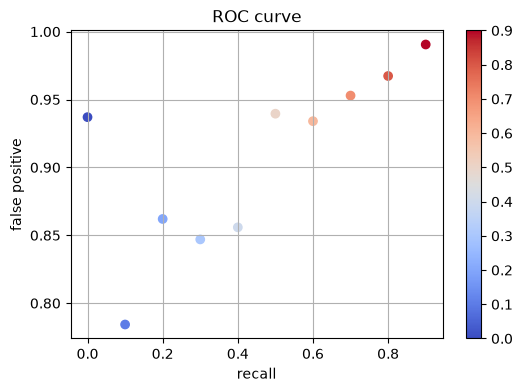

In [28]:
# TODO: Compute the 11-point interpolated precision–recall for each query, for both models
import numpy as np
import matplotlib.pyplot as plt

#r er faste presisjons verdier.... men jeg er aldri i nærheten av å ha 1 i presisjon....
#Forstår konseptet, men litt usikker på noen detaljer... Nevermind ser nå at det 
#står recall levels.
r = np.linspace(0,1,11)

# Your code here
#Det står at jeg skal gå gjennom hver eneste rank og regne ut precicion og recall...


average_precision_spread = [0] *10

for qid, q in queries.items():
    precision_spread = [[] for _ in range(10)]
    jelinek_ranking = jelinek_smoothing(q)
    #Gjør om til liste med bare relevant doc id, som er sortert
    jelinek_ranking = [rank[0] for rank in jelinek_ranking]
    relevant_docs = qrels[qid]

    recall : list[int] = []
    precision : list[int] = []

    #antall relevant docs som ikke er "funnet"
    relevant_docs_found = 0


    for index, docid in zip(range(0,len(jelinek_ranking)), jelinek_ranking):
        #Regner ut recall først
        if(docid in relevant_docs):
            relevant_docs_found += 1

        recall.append(relevant_docs_found/len(relevant_docs))

        #regner ut precision, dvs bare andelen av docs som er relevante ig
        precision.append(relevant_docs_found/(index+1))

    #Nå må jeg bare dele inn i de 10 kategoriene
    for i in range(0,len(recall)):
        for limit_index in range(0,len(r)):
            
            if (recall[i] <= (r[limit_index] + 0.1)):
                precision_spread[limit_index].append(precision[i])
                break

    # print(recall)
    # print(precision)
    # print(precision_spread)

    #nå må jeg bare ta gjennomsnittet av hver spread
    for i in range(0, len(precision_spread)):
        total: int = 0
        for j in range(0, len(precision_spread[i])):
            total+=precision_spread[i][j]


        if(len(precision_spread[i])!= 0):
            precision_spread[i] = total/len(precision_spread[i])

            average_precision_spread[i] += precision_spread[i]

    #for i in range(0, len(average_precision_spread)):
        
    # print(precision_spread)
    # print(average_precision_spread)
    

for i in range(0,len(average_precision_spread)):
    average_precision_spread[i] = average_precision_spread[i]/len(queries.keys())
    average_precision_spread[i] = 1-average_precision_spread[i]
print(average_precision_spread)

plt.figure(figsize=(6,4))
plt.scatter(r[0:10], average_precision_spread, c=r[0:10], cmap='coolwarm')
plt.grid(True)
plt.title("ROC curve")
plt.colorbar()
plt.xlabel("recall")
plt.ylabel("false positive")
plt.show()
